In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from src.components.Battery import Battery

In [3]:
from src.components.DieselGenerator import DieselGenerator

In [4]:
Battery.__dict__

mappingproxy({'__module__': 'src.components.Battery',
              '__doc__': '\n    Класс моделирования системы накопления электрической энергии (СНЭЭ)\n    A class that models a battery energy storage system (BESS).\n\n    Параметры (Parameters)\n    ----------\n    capacity: float\n        Номинальная энергоемкость, кВт·ч\n        Nominal energy capacity, kWh\n    soc_max: float\n        Максимально допустимый СЗ, %.\n        The maximum allowable SOC, %.\n    soc_min: float\n        Минимально допустимый СЗ, %.\n        The minimum allowable SOC, %.\n    r_power_ch: float\n        Номинальная предельная мощность заряда, кВт\n    r_power_ds: float\n        Номинальная предельная мощность разряда, кВт\n    eff_ch: float\n        Эффективность заряда, %\n        roundtrip efficiency charging, %.\n    eff_ds: float\n        Эффективность разряда, %\n        roundtrip efficiency discharging, %.\n    aux_p_ch: float\n        Мощность потребления вспомогательной подсистемы при заряде, кВ

In [5]:
DieselGenerator.__dict__

mappingproxy({'__module__': 'src.components.DieselGenerator',
              '__init__': <function src.components.DieselGenerator.DieselGenerator.__init__(self, num_DGs: int, r_capacity: float, a1: float, a2: float, start_stop_price: float, fuel_price: float)>,
              'get_DGs': <function src.components.DieselGenerator.DieselGenerator.get_DGs(self) -> numpy.ndarray>,
              'calculate_fuel_consumption': <function src.components.DieselGenerator.DieselGenerator.calculate_fuel_consumption(self, generate_array: numpy.ndarray, p: float = 860, k: float = 1.45) -> Tuple[numpy.ndarray, numpy.ndarray]>,
              'total_cost': <function src.components.DieselGenerator.DieselGenerator.total_cost(self, power: numpy.ndarray, u: numpy.ndarray, u_prev: numpy.ndarray, r_electricity: float) -> float>,
              'optimize_DGs': <function src.components.DieselGenerator.DieselGenerator.optimize_DGs(self, u_prev: numpy.ndarray, load: float, r_electricity: float)>,
              '__dict

In [44]:
df = pd.read_excel(r'C:\Users\Илья\PycharmProjects\masters-thesis\src\data\data.xlsx')
print(df)

                datetime   Сасыр, kW  Solal, kW
0    2019-01-01 00:00:00  201.000791        0.0
1    2019-01-01 01:00:00  179.721422        0.0
2    2019-01-01 02:00:00  171.304978        0.0
3    2019-01-01 03:00:00  173.068636        0.0
4    2019-01-01 04:00:00  159.528222        0.0
...                  ...         ...        ...
8755 2019-12-31 19:00:00  277.786301        0.0
8756 2019-12-31 20:00:00  238.908277        0.0
8757 2019-12-31 21:00:00  240.645576        0.0
8758 2019-12-31 22:00:00  200.358556        0.0
8759 2019-12-31 23:00:00  183.208797        0.0

[8760 rows x 3 columns]


In [6]:
index_of_california = df[df['Solal, kW'] > df['Сасыр, kW']].index
print(index_of_california)

Index([ 995, 1476, 1548, 1572, 1596, 1644, 1668, 1692, 1716, 1740,
       ...
       7067, 7091, 7115, 7139, 7163, 7187, 7211, 7235, 7259, 7283],
      dtype='int64', length=969)


In [27]:
load = df['Сасыр, kW'][7110:7145].to_numpy()
gen = df['Solal, kW'][7110:7145].to_numpy()

In [8]:
print(load)
print(gen)

[137.90903479 145.34880092 182.80576374 197.97426728 202.26595466
  19.07464281 210.         209.2203398  198.20541082 181.46736583
 189.06951807 178.20336848 208.97973423 199.9047578  202.8657728
 175.87040821 180.04928096 171.33427078 140.41304416 142.7967751
 129.84126063 129.60595267 121.26471989 120.21205114 139.16641387
 146.10205144 178.606746   198.69503741 198.87264692  22.88902265
 203.12260639 210.         200.0731759  176.41106828 190.66131703]
[  0.          27.67242437  54.38470588  89.81843658  96.11676572
 167.8561666   29.42856001  26.02980896  23.55203658  11.16048523
   0.97233402   0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
  10.56365827  24.57185595  31.98631163  45.95349241  39.60104609
  27.93159409  31.0120895   23.73421604  10.06038539   1.28065676]


In [24]:
BESS = (
    Battery(e_cr= 200,
        soc_max = 100,
        soc_min = 20,
        r_power_ch = 50,
        r_power_ds = 45,
        eff = 98,
        aux_power = 5,
        cp = 5))

TypeError: Battery.__init__() got an unexpected keyword argument 'e_cr'

In [6]:
num_DGs = 5
r_capacit = 110
a1, a2 = 0.0101, 0.2654
start_stop_price = 200
fuel_price = 27
DGs = DieselGenerator(num_DGs, r_capacit, a1, a2, start_stop_price, fuel_price)

In [7]:
DGs.get_DGs()

array([38.5, 38.5, 38.5, 38.5, 38.5])

In [ ]:
u_prev = np.array([1,1,0,0,0])
load = 418.0
r_electricity = 27
P_opt, u_opt, cost_opt = DGs.optimize_DGs(u_prev, load, r_electricity)
print("Оптимальные мощности:", P_opt)
print("Статус генераторов (1=вкл,0=выкл):", u_opt)
print("Минимальная стоимость:", cost_opt)

In [ ]:
import numpy as np
def calculate_fuel_consumption(generate_array: np.ndarray, a1 = 0.0101, a2 = 0.2654, p: float = 860, k: float = 1.45) -> Tuple[np.ndarray,np.ndarray]:
    """
    Зависимость расхода топлива от номинальной мощности и текущей нагрузки ДГУ
    The fuel consumption of the diesel generator (DG)
    Параметры (Parameters)
    ----------
    generate_array: np.ndarray
        Массив мощностей генераторов
        Array of diesel generator power outputs
    p : float, optional
        Плотность топлива, по умолчанию 860
        Fuel density, default 860
    k : float, optional
        Коэффициент теплотворной способности, по умолчанию 1.45
        Calorific value coefficient, default 1.45

    Возвращает (Returns)
    specific_cons: np.ndarray
        Удельный расход условного топлива
    total_cons: np.ndarray
        Абсолютный расход топлива
    ----------

    """
    specific_cons = np.zeros_like(generate_array, dtype=np.float64)
    mask = generate_array > 0
    specific_cons[mask] = a1 * generate_array[mask] + a2 * self.r_capacity
    total_cons =  specific_cons[mask] * generate_array[mask] / (p * k)

    return specific_cons, total_cons
def distribute_load_among_generators(DGs_running: np.ndarray,
load: float, r_capacity: float, p_min: float, p_max: float, start_stop_price: float, r_electricity: float) -> np.ndarray:
    pass
DGs_running = np.array([[38.5, 38.5, 38.5, 0, 0]])
r_capacity = 110
p_min = 0.35
p_max = 0.95
start_stop_price = 100
r_electricity = 27
load = 400

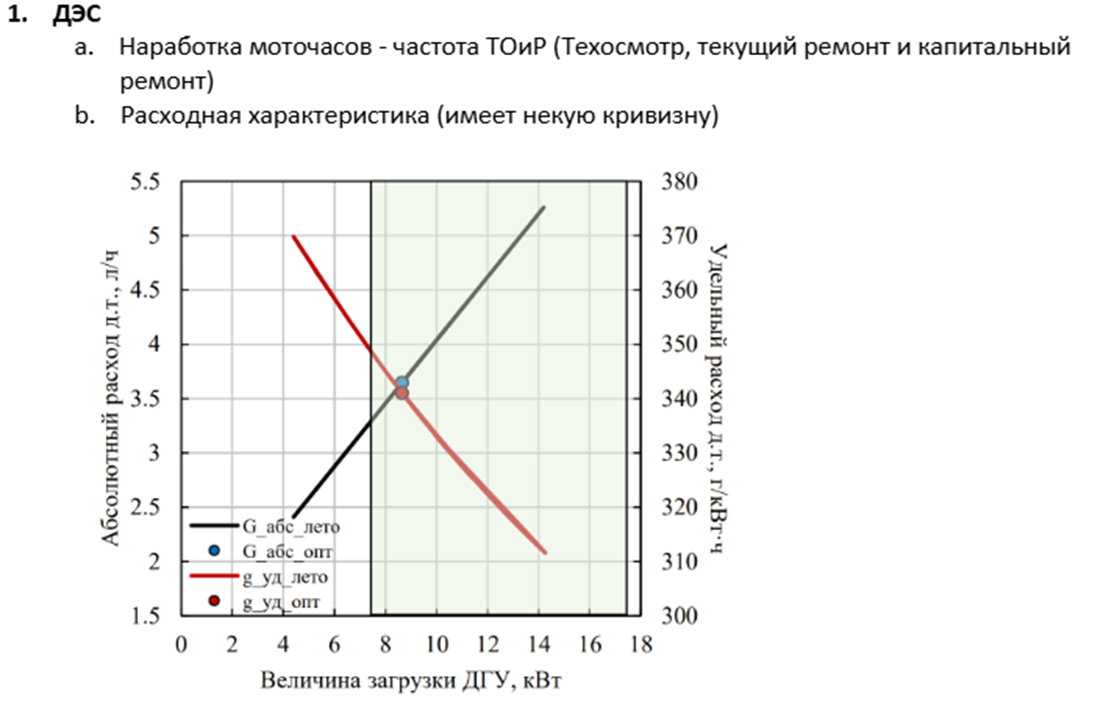

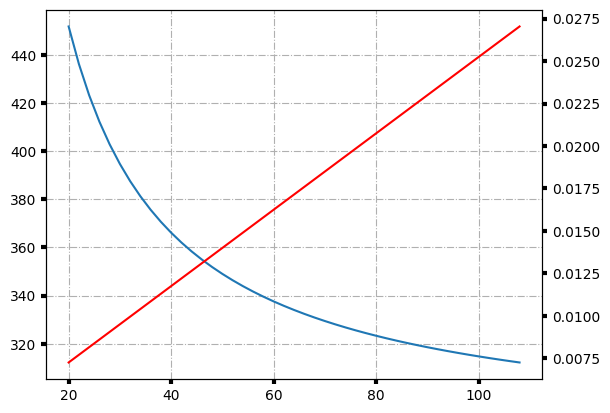

In [6]:
Qp = 10180
bnom = 210
eff_nom = 0.98
N_nom = 110
p = 860

N = np.arange(20, 110, 2)
b = bnom / eff_nom * (0.9 + 0.1/(N/N_nom)) * Qp/7000
Q = b * N / (1e3*(1.45 * p))
fig, ax1 = plt.subplots()
ax1.plot(N, b)
ax1.grid(True, linestyle='-.')
ax1.tick_params(labelsize='medium', width=3)

ax2 = ax1.twinx()
ax2.plot(N, Q,'r')
ax2.tick_params(labelsize='medium', width=3)

plt.show()